In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

In [9]:
df = pd.read_csv('diamond_encoded.csv')

df

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,4,5,1,61.5,55.0,326,3.95,3.98,2.43
1,0.21,3,5,2,59.8,61.0,326,3.89,3.84,2.31
2,0.23,1,5,4,56.9,65.0,327,4.05,4.07,2.31
3,0.29,3,1,3,62.4,58.0,334,4.20,4.23,2.63
4,0.31,1,0,1,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53789,0.72,4,6,2,60.8,57.0,2757,5.75,5.76,3.50
53790,0.72,1,6,2,63.1,55.0,2757,5.69,5.75,3.61
53791,0.70,2,6,2,62.8,60.0,2757,5.66,5.68,3.56
53792,0.86,3,2,1,61.0,58.0,2757,6.15,6.12,3.74


In [10]:
df.columns

Index(['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y',
       'z'],
      dtype='str')

In [11]:
## independent and dependent features 

x = df[['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'x', 'y','z']]

y = df['price']

In [12]:
## Train test split
from sklearn.model_selection import train_test_split

x_train , x_test , y_train , y_test = train_test_split(x,y , test_size=0.25 , random_state=42)

In [13]:
x_train.shape , x_test.shape , y_train.shape , y_test.shape

((40345, 9), (13449, 9), (40345,), (13449,))

In [15]:
## Standardization
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaler = scaler.fit_transform(x_train)
x_test_scaler = scaler.transform(x_test)

In [16]:
x_train , x_train_scaler

(       carat  cut  color  clarity  depth  table     x     y     z
 12789   1.02    4      3        3   62.4   57.0  6.47  6.36  4.00
 19955   1.05    2      4        5   61.3   59.0  6.48  6.56  4.00
 6084    0.91    3      3        2   62.6   58.0  6.17  6.14  3.85
 37872   0.32    4      6        5   60.9   57.0  4.39  4.45  2.70
 24808   1.52    3      3        3   61.9   56.0  7.39  7.28  4.54
 ...      ...  ...    ...      ...    ...    ...   ...   ...   ...
 11284   1.00    3      2        3   60.4   58.0  6.51  6.46  3.92
 44732   0.63    4      3        2   61.7   54.0  5.52  5.56  3.42
 38158   0.32    4      0        2   61.8   54.9  4.39  4.42  2.72
 860     0.90    3      0        2   62.8   59.0  6.13  6.03  3.82
 15795   1.01    3      3        4   62.7   58.0  6.36  6.31  3.97
 
 [40345 rows x 9 columns],
 array([[ 0.46389858,  0.98357438, -0.23777029, ...,  0.65508487,
          0.53973222,  0.66080276],
        [ 0.52690088, -0.80949003,  0.34912738, ...,  0.66397216,

Linear Regression
------------------------------
Linear Regression: Mean Absolute Error = 793.9690
Linear Regression: Mean Squared Error = 1424207.9122
Linear Regression: Root Mean Squared Error = 1193.4018
Linear Regression: R² Score = 0.9073



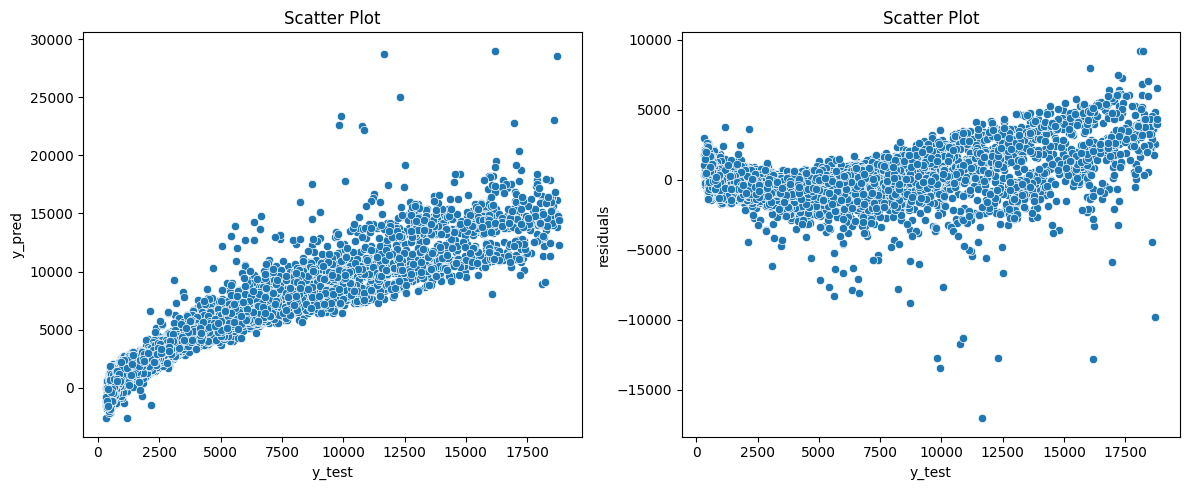

Ridge
------------------------------
Ridge: Mean Absolute Error = 794.3660
Ridge: Mean Squared Error = 1424247.4509
Ridge: Root Mean Squared Error = 1193.4184
Ridge: R² Score = 0.9073



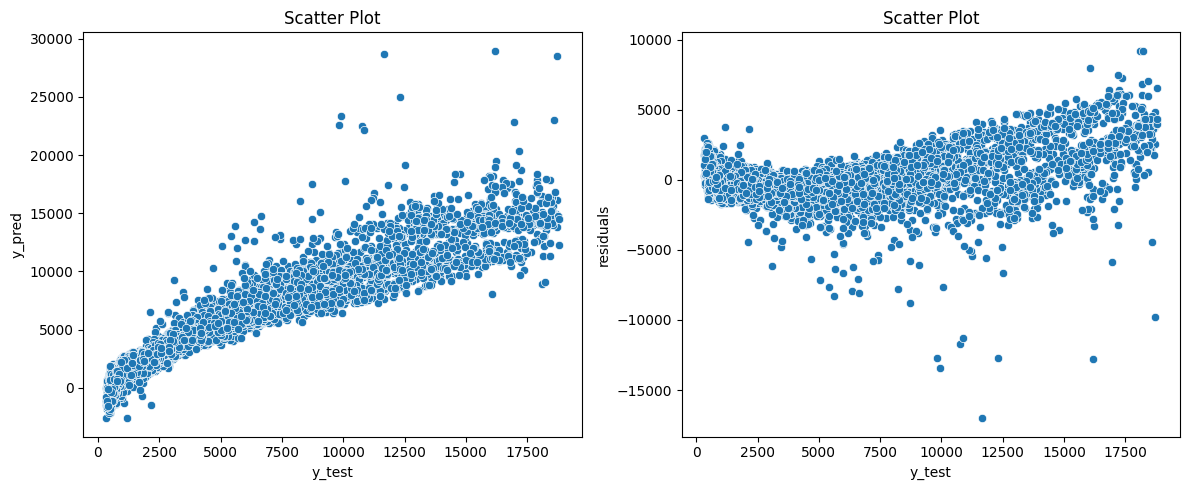

Lasso
------------------------------
Lasso: Mean Absolute Error = 795.8448
Lasso: Mean Squared Error = 1424195.9108
Lasso: Root Mean Squared Error = 1193.3968
Lasso: R² Score = 0.9073



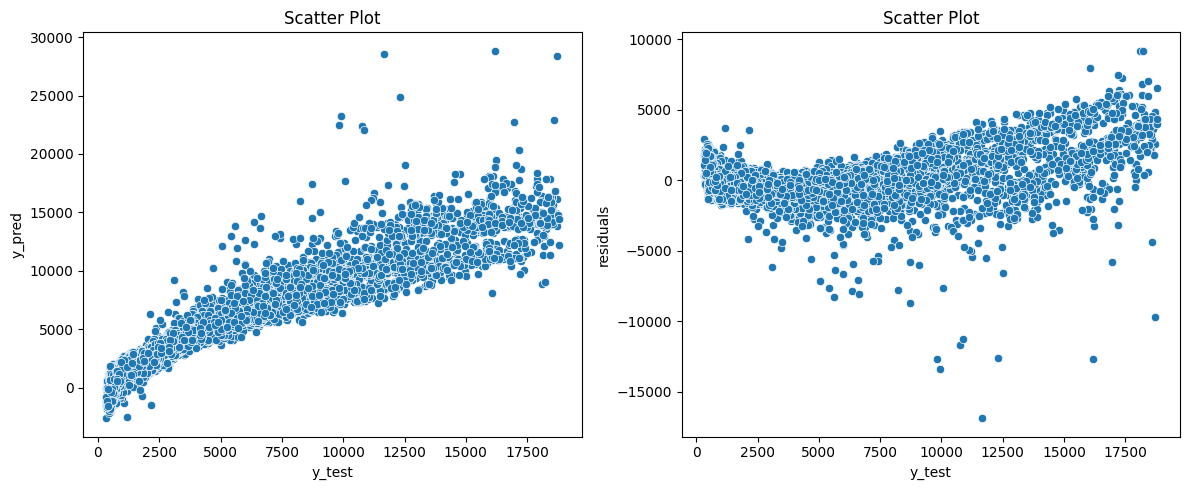

ElasticNet
------------------------------
ElasticNet: Mean Absolute Error = 1143.3131
ElasticNet: Mean Squared Error = 2863927.1779
ElasticNet: Root Mean Squared Error = 1692.3141
ElasticNet: R² Score = 0.8137



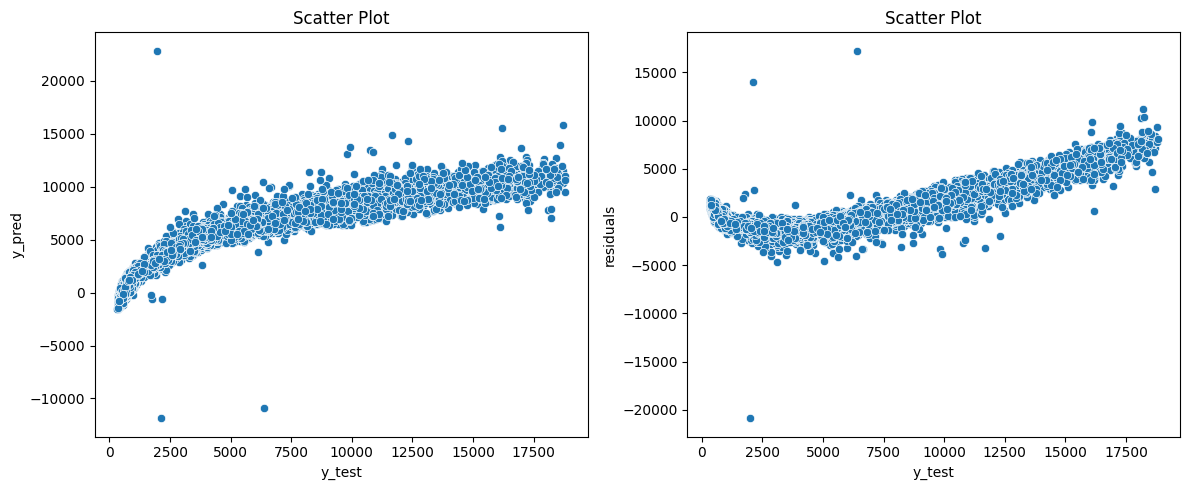

RidgeCV
------------------------------
RidgeCV: Mean Absolute Error = 794.3660
RidgeCV: Mean Squared Error = 1424247.4509
RidgeCV: Root Mean Squared Error = 1193.4184
RidgeCV: R² Score = 0.9073



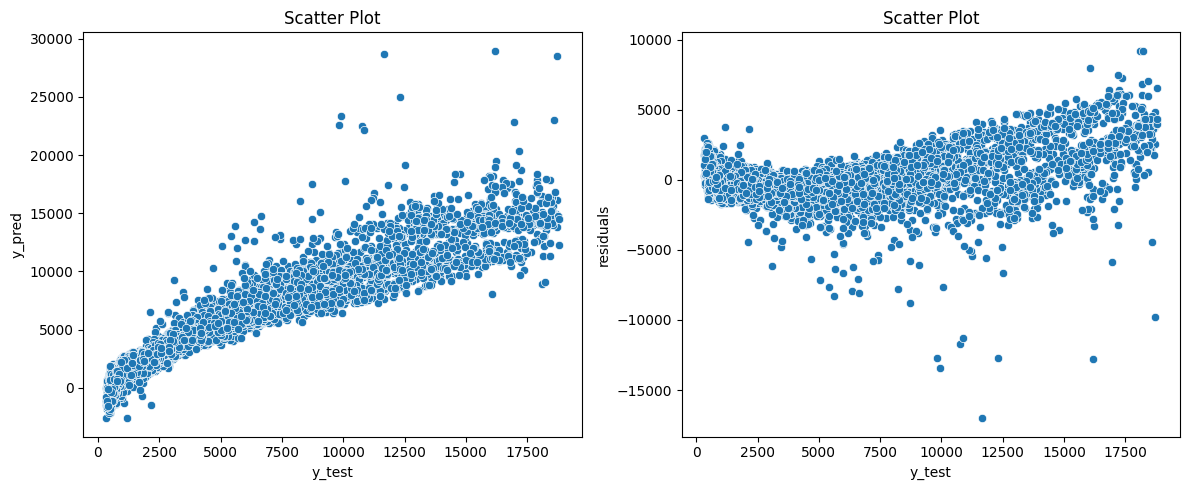

LassoCV
------------------------------
LassoCV: Mean Absolute Error = 802.9116
LassoCV: Mean Squared Error = 1428110.5804
LassoCV: Root Mean Squared Error = 1195.0358
LassoCV: R² Score = 0.9071



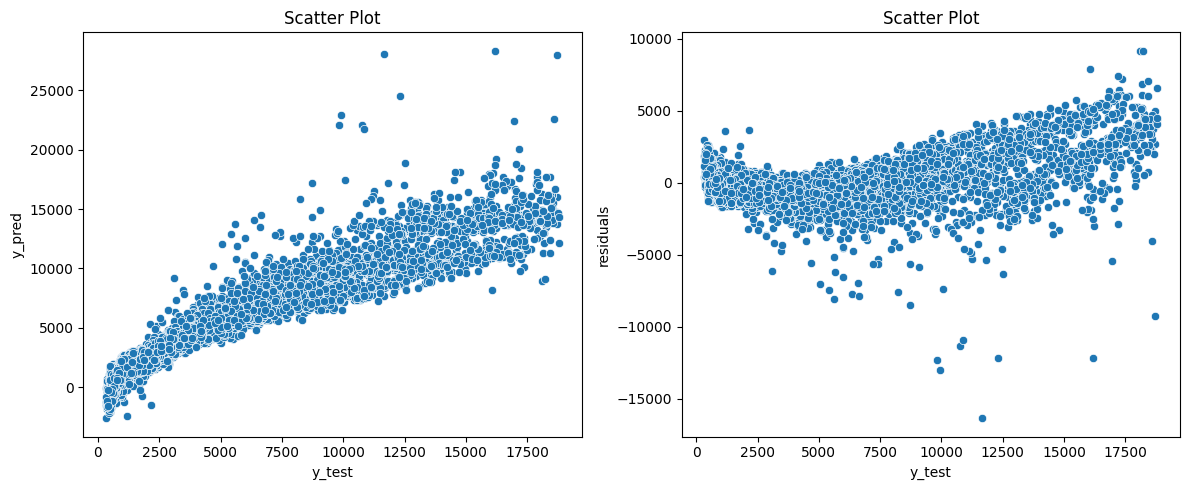

ElasticNetCV
------------------------------
ElasticNetCV: Mean Absolute Error = 1866.3538
ElasticNetCV: Mean Squared Error = 6986594.7172
ElasticNetCV: Root Mean Squared Error = 2643.2167
ElasticNetCV: R² Score = 0.5454



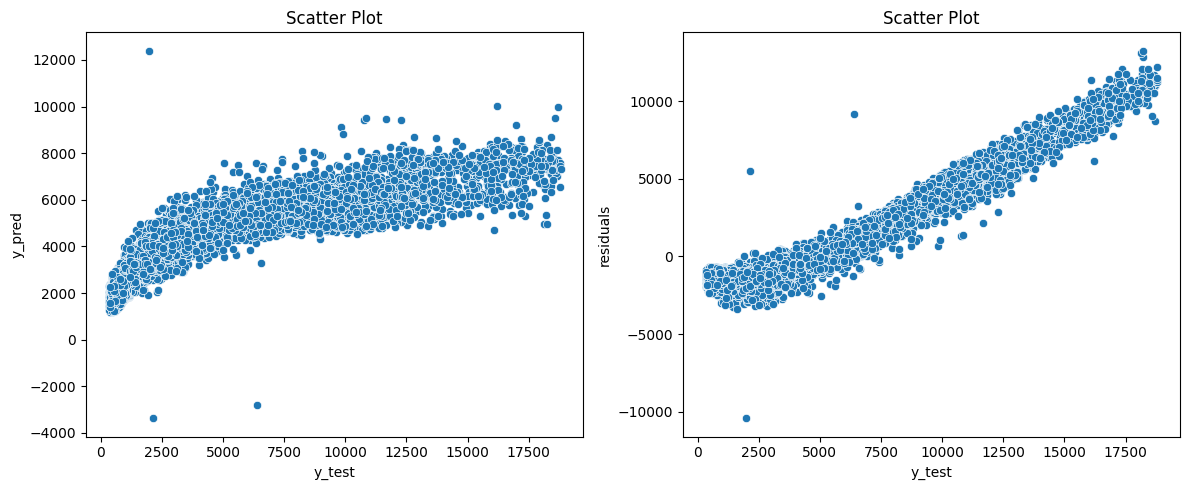

In [24]:
## Model Training 
import math
from sklearn.linear_model import LinearRegression , Ridge , Lasso , ElasticNet
from sklearn.linear_model import RidgeCV , LassoCV , ElasticNetCV
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score

models = {
    'Linear Regression' : LinearRegression() , 
    'Ridge' : Ridge() ,
    'Lasso' : Lasso() ,
    'ElasticNet' : ElasticNet(),
    'RidgeCV' : RidgeCV(cv=5) ,
    'LassoCV' : LassoCV(cv=5) ,
    'ElasticNetCV' : ElasticNetCV(cv=5)
}

# Train and Evaluate
for name, model in models.items():
    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)

    mae = mean_absolute_error(y_test , y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = math.sqrt(mse)
    score = r2_score(y_test, y_pred)

    print(f'{name}')
    print('-'*30)

    print(f"{name}: Mean Absolute Error = {mae:.4f}")
    print(f"{name}: Mean Squared Error = {mse:.4f}")
    print(f"{name}: Root Mean Squared Error = {rmse:.4f}")
    print(f"{name}: R² Score = {score:.4f}")
    print()

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    sns.scatterplot(x = y_test ,y =  y_pred)
    plt.title("Scatter Plot")
    plt.xlabel('y_test')
    plt.ylabel('y_pred')

    residuals = y_test - y_pred

    plt.subplot(1,2,2)
    sns.scatterplot(x = y_test , y = residuals)
    plt.title("Scatter Plot")
    plt.xlabel('y_test')
    plt.ylabel('residuals')

    plt.tight_layout()
    plt.show()


In [25]:
## Pickling the model and scaler 

import pickle

model = models['Linear Regression']
pickle.dump(model , open('/Users/dhruvitjalodhara/programming/ML Practice/Diamond Price Prediction/Models/model.pkl' , 'wb'))
pickle.dump(scaler , open('/Users/dhruvitjalodhara/programming/ML Practice/Diamond Price Prediction/Models/scaler.pkl' , 'wb'))